In [6]:
from sys import path as syspath
from os import path as ospath

syspath.insert(1, r'D:\ARTM\topic-modelling-attention\src')

In [2]:
import jax
import jax.numpy as jnp

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns

from cartm.model import ContextTopicModel
from cartm.preprocessing import DatasetPreprocessor
from cartm.metrics import TopicVarianceMetric
from cartm.regularization import (
    Regularization,
    DecorrelationRegularization,
)

In [7]:
import jax
jax.config.update('jax_num_cpu_devices', 8)
jax.devices()

[CpuDevice(id=0),
 CpuDevice(id=1),
 CpuDevice(id=2),
 CpuDevice(id=3),
 CpuDevice(id=4),
 CpuDevice(id=5),
 CpuDevice(id=6),
 CpuDevice(id=7)]

In [8]:
import jax.numpy as jnp
x = jnp.arange(5)
x.devices()
x.sharding
jax.debug.visualize_array_sharding(x)

  CPU 0  
         

In [ ]:
@jit
def f(x, neg):
  return -x if neg else x

f(1, True)

In [3]:
sns.set_theme()

This example notebook shows how to use predefined regularizations and write your own custom regularizations.

It is recommended to read `metrics.ipynb` notebook first.

In [4]:
data = fetch_20newsgroups(data_home='./data/', subset='all').data
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(' ')) for doc in data])}')

Total number of documents in corpus: 18846
Total number of words in corpus: 5937230


In [5]:
preprocessor = DatasetPreprocessor()
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of document boundaries in preprocessed corpus: {len(document_bounds)}')
print(f'Total number of tokenized words in preprocessed corpus: {len(tokenized_data)}')

Total number of document boundaries in preprocessed corpus: 18847
Total number of tokenized words in preprocessed corpus: 3005990


## Basic usage of predefined regularizations

### Creating new regularization

Each regularization represents a subclass of an abstract `Regularization` class. To define a new regularization and use it in your model, you can create an instance of the regularization you need and pass it to constructor of the model. Alternatively, you can use `add_regularization` method of `ContextTopicModel` class to add a new regularization after the creation of the model. To remove a regularization from the model, use `remove_regularization` method.

In [11]:
decorrelator = DecorrelationRegularization(tau=0.3)

model = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    regularizers=[decorrelator],
    n_topics=20,
)

model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    max_iter=5,
    verbose=1,
    seed=42,
)

Iteration [1/5], phi update diff norm: 0.1566
Iteration [2/5], phi update diff norm: 0.0097
Iteration [3/5], phi update diff norm: 0.0146
Iteration [4/5], phi update diff norm: 0.0224
Iteration [5/5], phi update diff norm: 0.0326


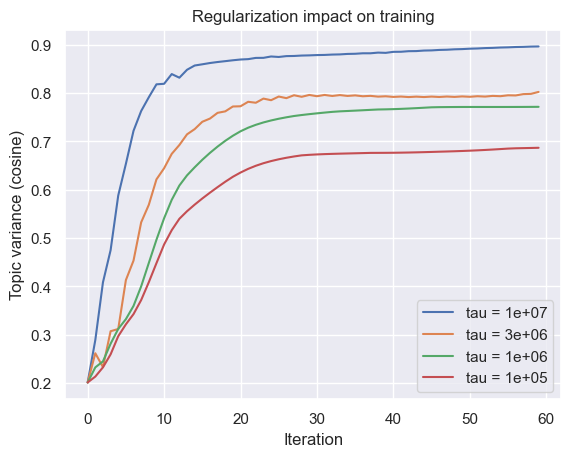

In [12]:
for tau in [1e7, 3e6, 1e6, 1e5]:
    decorrelator = DecorrelationRegularization(tau=tau)
    topic_variance_mtc = TopicVarianceMetric(distance_metric='cosine')

    model = ContextTopicModel(
        vocab_size=len(preprocessor.vocabulary),
        ctx_len=10,
        metrics=[topic_variance_mtc],
    )
    model.add_regularization(decorrelator)

    model.fit(
        data=tokenized_data,
        ctx_bounds=document_bounds,
        max_iter=60,
        verbose=0,
        seed=42,
    )

    plt.plot(topic_variance_mtc.history, label=f'tau = {tau:.1g}')

plt.title('Regularization impact on training')
plt.xlabel('Iteration')
plt.ylabel('Topic variance (cosine)')
plt.legend()
plt.show()

In [15]:
decorrelator = DecorrelationRegularization(tau=1e7)
topic_variance_mtc = TopicVarianceMetric(distance_metric='cosine')

model = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    metrics=[topic_variance_mtc],
    n_topics=20,
)
model.add_regularization(decorrelator)

model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    max_iter=60,
    verbose=1,
    seed=42,
)


In [16]:
phi_wt = model.phi  # p(w|t)
n_t = model.n_t  # denormalized distribution of topics
print(f'phi matrix type: {type(phi_wt)}, shape: {phi_wt.shape}')
print(f'n_t array type: {type(n_t)}, shape: {n_t.shape}')

phi matrix type: <class 'jaxlib._jax.ArrayImpl'>, shape: (90682, 20)
n_t array type: <class 'jaxlib._jax.ArrayImpl'>, shape: (20,)


In [17]:
# find top-10 words with the biggest probability p(w|t) for each topic t
topk = jnp.argsort(phi_wt, axis=0, descending=True)[:20, :].T

# create mapping token -> word from existing mapping word -> token (vocabulary)
vocabulary = preprocessor.vocabulary
reverse_vocab = {value: key for key, value in vocabulary.items()}

for topic_idx, t in enumerate(topk):
    print(f'Topic {topic_idx + 1}:', '\t'.join([reverse_vocab[int(idx)] for idx in t]))
    print()

Topic 1: berkeley	california	pittsburgh	angel	bnr	univ	april	lo	king	lab	laboratori	cornel	jeff	bell	south	jet	mellon	carnegi	tel	chicago

Topic 2: jim	gmt	stratu	eng	keith	corp	corpor	cramer	mot	east	serdar	optilink	argic	uunet	roger	ron	convex	princeton	microsoft	umich

Topic 3: columbia	germani	anti	ncr	boni	oracl	jake	nazi	cunixb	col	armi	finland	jack	gld	sol	franc	german	sweden	british	wayn

Topic 4: light	bob	radio	western	front	mile	night	auto	food	ride	door	rec	reserv	wire	tire	wall	sport	brake	motorcycl	tank

Topic 5: uiuc	cwru	cso	rochest	andi	ken	in	uxa	pt	wpi	ryan	marc	craig	umn	dseg	ucsd	engr	lehigh	nmsu	christoph

Topic 6: format	screen	unix	font	jpeg	copi	page	gif	convert	widget	print	text	motif	librari	printer	digex	function	mode	compil	directori

Topic 7: mil	bitnet	uni	uc	indiana	navi	illinoi	urbana	turk	chz	informatik	rlk	silver	andr	proceed	mari	beck	fij	blah	hamburg

Topic 8: drug	water	diseas	patient	doctor	blood	treatment	infect	dan	pain	batteri	msg	cancer	drink	

In [26]:
vocabulary['thi']

1497

In [16]:
tokenized_data

Array([66620, 28839, 57150, ...,  8442, 64179, 60768], dtype=int32)

In [17]:
document_bounds

Array([      0,      94,     188, ..., 3062004, 3062115, 3062270], dtype=int32)

In [ ]:
[(i, token) for i, token in enumerate(tokenized_data) if token == 69889]

In [23]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
stop_words

In [25]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
stemmer.stem("this")

'thi'

In [35]:
data[2]

'From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject: Re: ARMENIA SAYS IT COULD SHOOT DOWN TURKISH PLANES (Henrik)\nLines: 95\nNntp-Posting-Host: viktoria.dsv.su.se\nReply-To: hilmi-er@dsv.su.se (Hilmi Eren)\nOrganization: Dept. of Computer and Systems Sciences, Stockholm University\n\n\n\n\n|>The student of "regional killings" alias Davidian (not the Davidian religios sect) writes:\n\n\n|>Greater Armenia would stretch from Karabakh, to the Black Sea, to the\n|>Mediterranean, so if you use the term "Greater Armenia" use it with care.\n\n\n\tFinally you said what you dream about. Mediterranean???? That was new....\n\tThe area will be "greater" after some years, like your "holocaust" numbers......\n\n\n\n\n|>It has always been up to the Azeris to end their announced winning of Karabakh \n|>by removing the Armenians! When the president of Azerbaijan, Elchibey, came to \n|>power last year, he announced he would be be "swimming in Lake Sevan [in \n|>Armeniaxn] by July".\n\t\t*****\n\tIs\'t July 

## Tagging regularizations

Regularizations support tags (labels) for custom naming. Thus, you can use one regularization with different parameters in one model. 

Pay attention that, due to differentiation rules, using multiple instances of one regularization with different regularization coefficients (tau) is equivalent to using only one regularization with tau equal to the sum of regularization coefficients.

In [9]:
decorrelator = DecorrelationRegularization(
    tau=0.3, tag='decorrelation'
)

model = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    regularizers=[decorrelator],
)

model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    max_iter=5,
    verbose=1,
    seed=42,
)
model.remove_regularization(tag='decorrelation')

Iteration [1/5], phi update diff norm: 0.1164
Iteration [2/5], phi update diff norm: 0.0061
Iteration [3/5], phi update diff norm: 0.0084
Iteration [4/5], phi update diff norm: 0.0120
Iteration [5/5], phi update diff norm: 0.0166


## Advanced usage of regularizations

### Creating a custom regularization

Creating a new regularization requires creating a subclass of `Regularization` base class and implementing `__init__` and `_call_impl` methods. It is necessary to implement regularizations to be compatible with `jax.grad`.

In [8]:
class PhiNormRegularization(Regularization):
    def __init__(self, tau: float, tag: str = None):
        if tag is None:
            tag = self.__class__.__name__
        super().__init__(tag=tag, tau=tau)  # tau is applied in base class wrapper

    def _call_impl(self, phi_wt: jax.Array) -> float:
        norm = jnp.sum(phi_wt)
        return norm  # do not apply tau coefficient here!

In [9]:
custom_reg = PhiNormRegularization(tau=0.3)
reg_grad = jax.grad(custom_reg)

# if this line works correctly, everything is likely
# to be ok with your regularization
reg_grad(jnp.zeros((5, 5)))

Array([[0.3, 0.3, 0.3, 0.3, 0.3],
       [0.3, 0.3, 0.3, 0.3, 0.3],
       [0.3, 0.3, 0.3, 0.3, 0.3],
       [0.3, 0.3, 0.3, 0.3, 0.3],
       [0.3, 0.3, 0.3, 0.3, 0.3]], dtype=float32)

In [10]:
norm_regularization = PhiNormRegularization(tau=0.3)

model = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
)
model.add_regularization(norm_regularization)

model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    max_iter=5,
    verbose=2,
    seed=42,
)

Iteration [1/5], phi update diff norm: 0.1357
Iteration [2/5], phi update diff norm: 0.0177
Iteration [3/5], phi update diff norm: 0.0221
Iteration [4/5], phi update diff norm: 0.0360
Iteration [5/5], phi update diff norm: 0.0545
